In [4]:
from infalling_clouds import *
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as C
import latexify
import os
from flow_props import mass_evolution, vel_evolution, StratifiedBox
from tqdm.notebook import tqdm
import itertools


def get_v_mass_at_tff(r0, h, vturb, tcool=None, drag_bool = True):
    """
    Optimized version - only get final values without interpolation
    """
    if tcool is None: 
        cloud = TurbFallingCloud(h, r0, vturb=vturb)
    else: 
        cloud = TurbFallingCloud(h, r0, vturb=vturb, tcool=tcool)
    
    # FAST: Just get the solution without dense_output if you only need final values
    tcc = 1* 10 * r0 / vturb
    sol = cloud.integrate(tcc, stop_mode='time', dense_output=False, drag_bool = drag_bool)
    
    # Get final values directly from the solution arrays
    z_final = sol.y[0, -1]
    v_final = -sol.y[1, -1]
    m_final = sol.y[2, -1]
    m_initial = sol.y[2, 0]
    print(tcc)
    
    return m_final/m_initial, v_final/1000


def get_v_mass_sim(rundir):
    sim = StratifiedBox(os.path.join(rundir, 'strat.in'), dir=rundir)
    times, norm_mass, cgout, wgout, total = mass_evolution(rundir, gout=True)
    tvs, vel = vel_evolution(rundir)
    mask = ~np.isnan(norm_mass)
    timeseries = times/sim.t_eddy - 6
    idx_0 = np.argmin(np.abs(timeseries))
    norm_mass = norm_mass- norm_mass[idx_0]

    timeseries = timeseries[mask] * sim.t_eddy * sim.code_times_cgs / u.Myr.to('s')
    norm_mass = 10**norm_mass[mask]
    vel = vel[mask]

    #Identify tff
    tcc = 1 * 10 * sim.r_cloud_inserted /15 
    idx = np.argmin(np.abs(timeseries - tcc))
    print(timeseries[idx])

    return norm_mass[idx], vel[idx]



In [5]:
m, v = get_v_mass_sim('/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r100/t1e4')
print("this is v: ", v)
print(m)

59.353291382537634
this is v:  46.22863371570714
17.822918668118387


In [6]:
nm, nv = get_v_mass_at_tff(100, 3, 15, tcool=1e-3)
print(nv)
print(nm)

The solver successfully reached the end of the integration interval.
66.66666666666667
43.02255050839001
49.319580393913284


In [4]:
base_dir = "/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/"


# ------------------------------------------------------------
# 1. List all subdirectories starting with "t1e" inside any r* directory
#    and also list the r* directories (whose names encode a float after 'r')
# ------------------------------------------------------------
r_dirs = []

for entry in os.listdir(base_dir):
    full_path = os.path.join(base_dir, entry)

    if os.path.isdir(full_path) and entry.startswith("r"):
        try:
            float(entry[1:])
            r_dirs.append(entry)
        except ValueError:
            pass

t1e_paths = []   # full paths
for r in r_dirs:
    r_path = os.path.join(base_dir, r)
    for entry in os.listdir(r_path):
        path = os.path.join(r_path, entry)
        if os.path.isdir(path) and entry.startswith("t1e"):
            t1e_paths.append(path)


# ------------------------------------------------------------
# 2. Make a list of the radius values (floats) from r* directory names
# ------------------------------------------------------------
simm = []
simv = []
comm = []
comv = []


radii = [float(r[1:]) for r in r_dirs]


digits = []
rclvals = []
for tdir in t1e_paths:
    sim = StratifiedBox(os.path.join(tdir,'strat.in'), tdir)
    digit = np.log10(sim.compute_restart_cooling_time())

    
    digits.append(digit)
    sm, sv = get_v_mass_sim(tdir)
    simm.append(sm)
    simv.append(sv)
    rclvals.append(sim.r_cloud_inserted)

digit_min = min(digits)
digit_max = max(digits)


logspace_r = np.logspace(min(np.log10(radii) - 0.5), max(np.log10(radii) + 0.1), 30)
logspace_cooling = np.logspace(digit_min, digit_max, 30)


combs = list(itertools.product(logspace_r,logspace_cooling))


# Computations
for rcl, tcool in tqdm(combs):
    nm, nv = get_v_mass_at_tff(rcl, 3, vturb = 15, tcool=tcool)
    comm.append(np.log10(nm))
    comv.append(nv)

    

Cooling time at restart conditions: 1.635e-03 Myrs
0.05997329138260746
Cooling time at restart conditions: 1.635e-02 Myrs
0.05997329138260746
Cooling time at restart conditions: 1.635e-05 Myrs
0.05997329138260746
Cooling time at restart conditions: 1.635e-04 Myrs
0.05997329138260746
Cooling time at restart conditions: 1.061e-02 Myrs
56.28329138253768
Cooling time at restart conditions: 1.061e-06 Myrs
59.97329138253762
Cooling time at restart conditions: 1.061e-01 Myrs
52.80329138253764
Cooling time at restart conditions: 1.061e-05 Myrs
59.963291382537754
Cooling time at restart conditions: 1.061e-04 Myrs
59.97329138253762
Cooling time at restart conditions: 1.061e-03 Myrs
59.353291382537634
Cooling time at restart conditions: 1.653e-03 Myrs
0.599732913825378
Cooling time at restart conditions: 1.653e-03 Myrs
0.599732913825378
Cooling time at restart conditions: 1.653e-04 Myrs
0.599732913825378
Cooling time at restart conditions: 1.653e-02 Myrs
0.599732913825378
Cooling time at restart 

  0%|          | 0/900 [00:00<?, ?it/s]

The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver

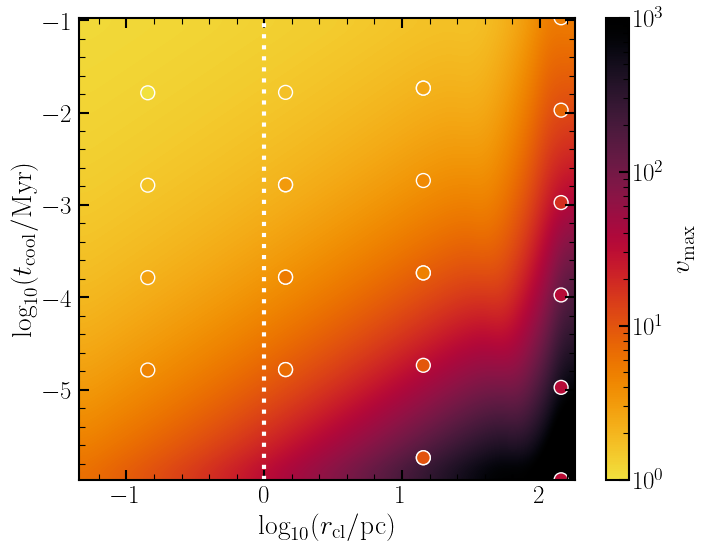

In [14]:
import cmasher as cmr
from matplotlib.colors import LogNorm
vmin = 1
vmax = 1e3
cmap = cmr.ember_r
norm = LogNorm(vmin=vmin, vmax=vmax)

# normalization
mrat = np.reshape(pow(10, np.array(comm)), (len(logspace_r), len(logspace_cooling))).copy().T
z_mm = mrat
x_m = np.log10(logspace_r/0.7)
y_m = np.log10(logspace_cooling)
extent = [x_m.min(), x_m.max(), y_m.min(), y_m.max()]

plt.style.use('custom_plot')
plt.figure(figsize=(8,6))

# imshow with LogNorm
cnt = plt.imshow(z_mm, origin='lower', extent=extent, aspect='auto',
                 cmap=cmap, norm=norm, interpolation='bicubic')

plt.colorbar(cnt, label=r'$v_{\rm max}$')

# scatter points
vals = np.clip(np.array(simm), vmin, vmax)  # clip to the same range
plt.scatter(np.log10(np.array(rclvals)/0.7), digits,
            c=vals, cmap=cmap, norm=norm,
            edgecolors='white', marker='o', s=100) 
plt.axvline(0, linestyle=':', color='white')

plt.xlabel(r"$\log_{10}(r_{\rm cl}/{\rm pc})$")
plt.ylabel(r"$\log_{10}(t_{\rm cool}/{\rm Myr})$")
plt.grid(visible=False)
plt.show()

[np.float64(-9.104004020118646), np.float64(-8.077896868934086), np.float64(-8.95363701235696), np.float64(-8.487309256727494), np.float64(70.18319058534667), np.float64(53.017608967658326), np.float64(68.91980117742447), np.float64(50.81772738228729), np.float64(51.674222940469974), np.float64(46.22863371570714), np.float64(-0.9539152567749662), np.float64(-0.9539152567749662), np.float64(-0.3744886242081043), np.float64(0.253089292845712), np.float64(0.16709918902058638), np.float64(0.03905185380291258), np.float64(-0.3744886242081043), np.float64(5.833244752358859), np.float64(7.598631000888641), np.float64(3.8705394361703225), np.float64(5.150109678539303), np.float64(7.598631000888641), np.float64(3.7866493148587614), np.float64(3.4995029414789403), np.float64(5.150109678539303)]


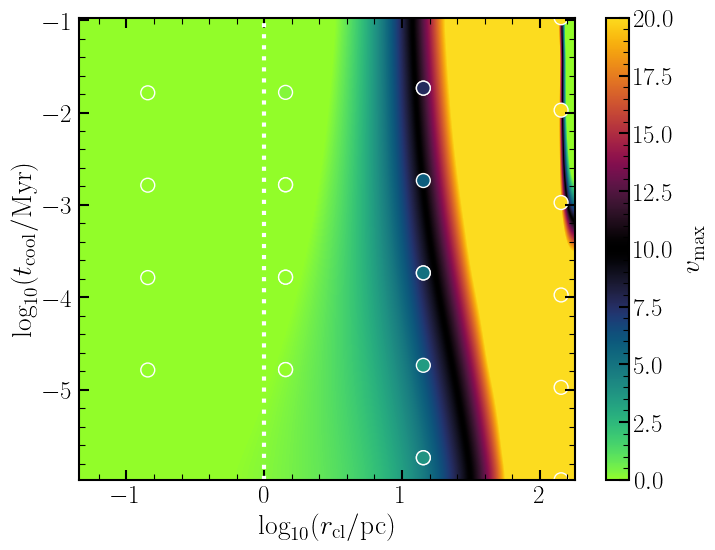

In [6]:
import cmasher as cmr
from matplotlib.colors import LogNorm
vmin = 0
vmax = 20
cmap = cmr.wildfire
norm = plt.Normalize(vmin=vmin, vmax=vmax)

# normalization
mrat = np.reshape(comv, (len(logspace_r), len(logspace_cooling))).copy().T
z_m = mrat
x_m = np.log10(logspace_r/0.7)
y_m = np.log10(logspace_cooling)
extent = [x_m.min(), x_m.max(), y_m.min(), y_m.max()]

plt.style.use('custom_plot')
plt.figure(figsize=(8,6))

# imshow with LogNorm
cnt = plt.imshow(z_m, origin='lower', extent=extent, aspect='auto',
                 cmap=cmap, norm=norm, interpolation='bicubic')

plt.colorbar(cnt, label=r'$v_{\rm max}$')

# scatter points
print(simv)
vals = np.clip(simv, vmin, vmax)  # clip to the same range
plt.scatter(np.log10(np.array(rclvals)/0.7), digits,
            c=vals, cmap=cmap, norm=norm,
            edgecolors='white', marker='o', s=100) 
plt.axvline(0, linestyle=':', color='white')

plt.xlabel(r"$\log_{10}(r_{\rm cl}/{\rm pc})$")
plt.ylabel(r"$\log_{10}(t_{\rm cool}/{\rm Myr})$")
plt.grid(visible=False)
plt.show()

In [7]:
def get_tgrow_over_tcc_at_vmax(r0,h,vturb, tcool):
        
    # Run model
    cloud = TurbFallingCloud(h,r0, vturb=vturb, tcool=tcool)
    

    sol = cloud.integrate(0.01, stop_mode='height')

    if len(sol.t_events[0]) > 0:
        t_end = sol.t_events[0][0]
    else:
        t_end = sol.t[-1]

    # Convert to a continuous solution
    t_range = np.linspace(0, t_end, 1000)
    solution = sol.sol(t_range)


    # compute L
    z = solution[0]
    v = -solution[1]
    m = solution[2]

    idx_vmax = np.argmax(v)
    
    
    tgrow_vmax = cloud.vTgrow(z[idx_vmax], v[idx_vmax], m[idx_vmax]) * 1e2 / cloud.profile_g(z[idx_vmax])
    tcc_vmax = np.sqrt(cloud.profile_T(z[idx_vmax])/1e4)*r0 * u.pc.to('m')/v[idx_vmax]

    return tgrow_vmax/tcc_vmax, v[idx_vmax]

In [8]:
combs = list(itertools.product(logspace_r, logspace_cooling))
fclst = []
vmlst = []
for rcl, tcool in tqdm(combs):
    tt, vm = get_tgrow_over_tcc_at_vmax(rcl,3, vturb=10, tcool=tcool)
    fclst.append(tt)
    vmlst.append(vm)

  0%|          | 0/900 [00:00<?, ?it/s]

/u/ferhi/own_package/plots/infalling_clouds.py:111: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \


A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.


/u/ferhi/own_package/plots/infalling_clouds.py:127: RuntimeWarning: invalid value encountered in scalar power
  tgrow = self.tgrow0 * u.Myr.to('s') * vrat**(3/5.) * tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)


A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A termination event occurred.
A terminat

[np.float64(-9.104004020118646), np.float64(-8.077896868934086), np.float64(-8.95363701235696), np.float64(-8.487309256727494), np.float64(70.18319058534667), np.float64(53.017608967658326), np.float64(68.91980117742447), np.float64(50.81772738228729), np.float64(51.674222940469974), np.float64(46.22863371570714), np.float64(-0.9539152567749662), np.float64(-0.9539152567749662), np.float64(-0.3744886242081043), np.float64(0.253089292845712), np.float64(0.16709918902058638), np.float64(0.03905185380291258), np.float64(-0.3744886242081043), np.float64(5.833244752358859), np.float64(7.598631000888641), np.float64(3.8705394361703225), np.float64(5.150109678539303), np.float64(7.598631000888641), np.float64(3.7866493148587614), np.float64(3.4995029414789403), np.float64(5.150109678539303)]


(-6.0, -1.0)

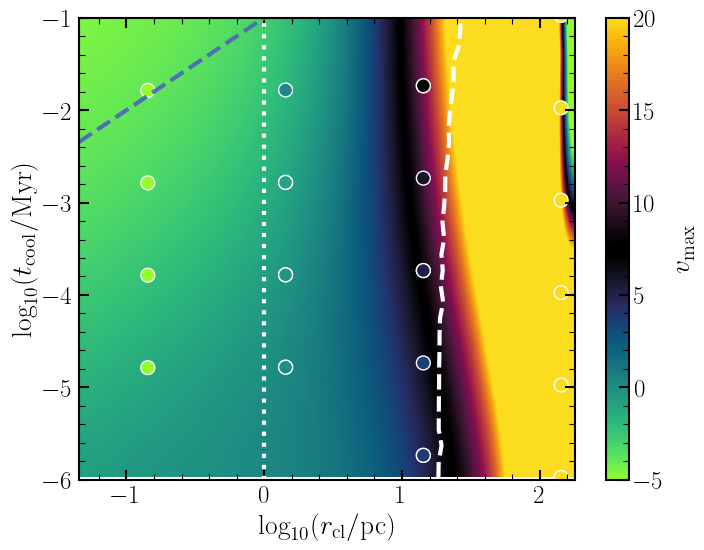

In [9]:
vmin = -5
vmax = 20
cmap = cmr.wildfire
norm = plt.Normalize(vmin=vmin, vmax=vmax)

# normalization
mrat = np.reshape(comv, (len(logspace_r), len(logspace_cooling))).copy().T
z_m = mrat
x_m = np.log10(logspace_r/0.7)
y_m = np.log10(logspace_cooling)
extent = [x_m.min(), x_m.max(), y_m.min(), y_m.max()]

plt.style.use('custom_plot')
plt.figure(figsize=(8,6))

# imshow with LogNorm
cnt = plt.imshow(z_m, origin='lower', extent=extent, aspect='auto',
                 cmap=cmap, norm=norm, interpolation='bicubic')

plt.colorbar(cnt, label=r'$v_{\rm max}$')

# scatter points
print(simv)
vals = np.clip(simv, vmin, vmax)  # clip to the same range
plt.scatter(np.log10(np.array(rclvals)/0.7), digits,
            c=vals, cmap=cmap, norm=norm,
            edgecolors='white', marker='o', s=100) 
plt.axvline(0, linestyle=':', color='white')

plt.xlabel(r"$\log_{10}(r_{\rm cl}/{\rm pc})$")
plt.ylabel(r"$\log_{10}(t_{\rm cool}/{\rm Myr})$")
plt.grid(visible=False)

trat_arr = np.reshape(fclst,(len(logspace_r),len(logspace_cooling))).copy().T
plt.contour(np.log10(logspace_r/0.7),np.log10(logspace_cooling),trat_arr,levels=[4],colors='white',linestyles='dashed')
plt.plot(np.log10(logspace_r/0.7), np.log10(logspace_r/0.7) - 1, linestyle= "dashed")
plt.ylim(bottom=-6, top=-1)

In [12]:
# Computations
cv_nodrag = []
cm_nodrag = []
for rcl, tcool in tqdm(combs):
    nm, nv = get_v_mass_at_tff(rcl, 3, vturb = 15, tcool=tcool, drag_bool=False)
    cv_nodrag.append(nv)
    cm_nodrag.append(nm)
vz_nodrag = np.reshape(cv_nodrag, (len(logspace_r), len(logspace_cooling))).copy().T
mz_nodrag = np.reshape(cm_nodrag, (len(logspace_r), len(logspace_cooling))).copy().T

  0%|          | 0/900 [00:00<?, ?it/s]

/u/ferhi/own_package/plots/infalling_clouds.py:111: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/u/ferhi/own_package/plots/infalling_clouds.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  vrat = 150. / min(abs(v)/1000, 150.)


The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver successfully reached the end of the integration interval.
0.018973665961010275
The solver

5


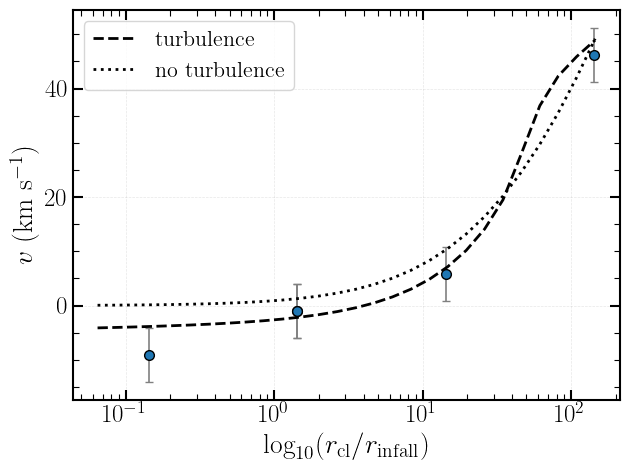

In [ ]:
indices = [i for i, v in enumerate(digits) if -3 < v < -2]

# Selected values
selected_paths = [t1e_paths[i] for i in indices]
vs = np.array([simv[i] for i in indices])
rs = np.array([rclvals[i] for i in indices])

print(len(selected_paths))

# ---------------------
# SCATTER WITH ERRORBARS
# ---------------------
plt.errorbar(
    rs/0.7, vs,
    yerr=5,              # ±5
    fmt='o',             # circular marker
    color='tab:blue',    # default color
    ecolor='gray',       # error bar color
    elinewidth=1.2,
    capsize=3,
    markersize=7,
    markeredgecolor='black'
)

# ---------------------
# FIXED COOLING SLICE: y = 10^-2
# ---------------------
target_log_y = -2
idx_y = np.argmin(np.abs(y_m - target_log_y))

z_slice = z_m[idx_y, :]   # 1D z values at that cooling
x_slice = x_m             # log10(r / 0.7)

# Convert x back to linear radius (divide by 0.7 like your scatter)
x_vals = 10**x_slice / 0.7
z_nodrag = vz_nodrag[idx_y, :]

# ---------------------
# SLICED LINE (BLACK + DASHED)
# ---------------------
plt.plot(
    x_vals[:-2],
    z_slice[:-2],
    color='black',
    linestyle='--',
    linewidth=2,
    label=r"turbulence"
)
# ---------------------
# SLICED NO DRAG (BLACK + DOTTED)
# ---------------------
plt.plot(
    x_vals[:-2],
    z_nodrag[:-2],
    color='black',
    linestyle=':',
    linewidth=2,
    label=r"no turbulence"
)
# ---------------------
# AXES & LABELS
# ---------------------
plt.xscale('log')
plt.xlabel(r'$\log_{10}(r_{\rm cl} / r_{\rm infall})$')
plt.ylabel(r'$v$ (km s$^{-1}$)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig('v_r_plot.png')

5


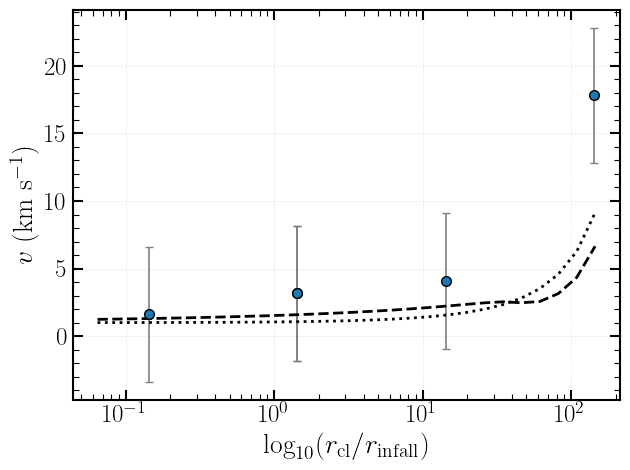

In [15]:
indices = [i for i, v in enumerate(digits) if -3 < v < -2]

# Selected values
selected_paths = [t1e_paths[i] for i in indices]
ms = np.array([simm[i] for i in indices])
rs = np.array([rclvals[i] for i in indices])

print(len(selected_paths))

# ---------------------
# SCATTER WITH ERRORBARS
# ---------------------
plt.errorbar(
    rs/0.7, ms,
    yerr=5,              # ±5
    fmt='o',             # circular marker
    color='tab:blue',    # default color
    ecolor='gray',       # error bar color
    elinewidth=1.2,
    capsize=3,
    markersize=7,
    markeredgecolor='black'
)

# ---------------------
# FIXED COOLING SLICE: y = 10^-2
# ---------------------
target_log_y = -2
idx_y = np.argmin(np.abs(y_m - target_log_y))

z_slice = z_mm[idx_y, :]   # 1D z values at that cooling
x_slice = x_m             # log10(r / 0.7)

# Convert x back to linear radius (divide by 0.7 like your scatter)
x_vals = 10**x_slice / 0.7
z_nodrag = mz_nodrag[idx_y, :]

# ---------------------
# SLICED LINE (BLACK + DASHED)
# ---------------------
plt.plot(
    x_vals[:-2],
    z_slice[:-2],
    color='black',
    linestyle='--',
    linewidth=2,
    label=r"$t_{\rm cool}=10^{-2}$ slice"
)
# ---------------------
# SLICED NO DRAG (BLACK + DOTTED)
# ---------------------
plt.plot(
    x_vals[:-2],
    z_nodrag[:-2],
    color='black',
    linestyle=':',
    linewidth=2,
    label=r"$t_{\rm cool}=10^{-2}$ slice"
)
# ---------------------
# AXES & LABELS
# ---------------------
plt.xscale('log')
plt.xlabel(r'$\log_{10}(r_{\rm cl} / r_{\rm infall})$')
plt.ylabel(r'$v$ (km s$^{-1}$)')
plt.grid(alpha=0.3)
plt.tight_layout()
